# 07 — Resilience: targeted vs. random attack (Course topic L9)

**Semiconductor Supply Chain — Network Analysis**

The decisive test of the hypothesis:

> *"removal of 3–5 hub nodes (TSMC, ASML, Shin-Etsu, Air Products, an ARM
> licensor) causes **catastrophic fragmentation** of the giant connected
> component."*

We knock nodes out in three orders — by **degree**, by **betweenness**, and at
**random** — and watch the giant component shrink.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'scripts' / 'analysis.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import analysis

D = analysis.company_supply_digraph()
U = analysis.company_supply_undirected()
N = U.number_of_nodes()

def attack(G0, order):
    G = G0.copy()
    xs, ys = [0.0], [1.0]
    for i, node in enumerate(order):
        if node in G:
            G.remove_node(node)
        xs.append((i + 1) / N)
        gcc = max((len(c) for c in nx.connected_components(G)), default=0)
        ys.append(gcc / N)
    return np.array(xs), np.array(ys)
print(f'{N} firms in the SUPPLIES projection')

108 firms in the SUPPLIES projection


## 1. Attack orders

Targeted orders use centrality computed on the *initial* graph (non-adaptive).
The random curve is averaged over 30 shuffles.

In [2]:
deg_order = [n for n, _ in sorted(U.degree(), key=lambda x: x[1], reverse=True)]
bet = nx.betweenness_centrality(D)
bet_order = sorted(bet, key=bet.get, reverse=True)

x, y_deg = attack(U, deg_order)
_, y_bet = attack(U, bet_order)

rng = np.random.default_rng(0)
nodes = list(U.nodes())
runs = []
for _ in range(30):
    rng.shuffle(nodes)
    _, yr = attack(U, list(nodes))
    runs.append(yr)
y_rand = np.mean(runs, axis=0)
print('done')

done

## 2. Visualise — resilience curves

saved C:\Users\Max\Desktop\project\reports\figures\07_resilience.png


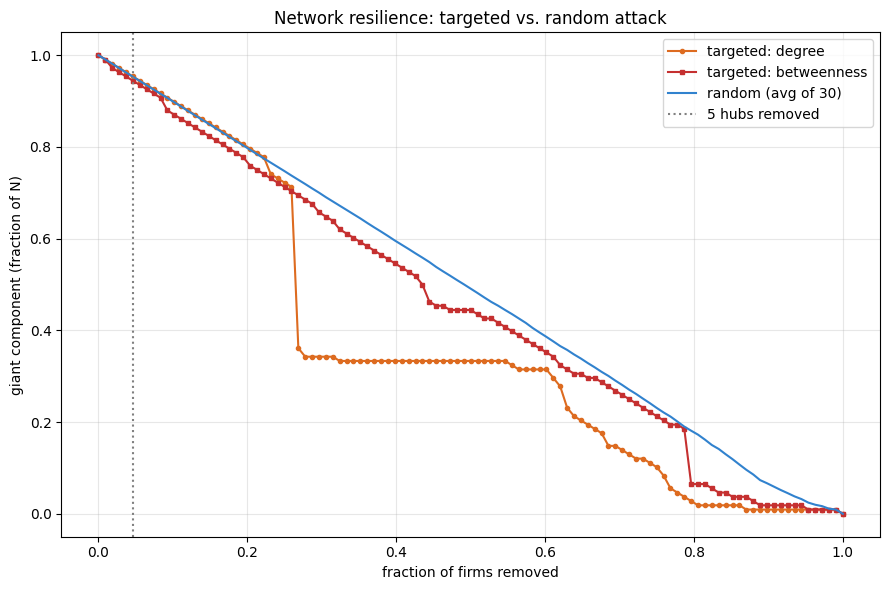

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x, y_deg, '-o', ms=3, color='#dd6b20', label='targeted: degree')
ax.plot(x, y_bet, '-s', ms=3, color='#c53030', label='targeted: betweenness')
ax.plot(x, y_rand, '-', color='#3182ce', label='random (avg of 30)')
ax.axvline(5 / N, color='gray', ls=':', label='5 hubs removed')
ax.set(xlabel='fraction of firms removed', ylabel='giant component (fraction of N)',
       title='Network resilience: targeted vs. random attack')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
out = analysis.FIGURES / '07_resilience.png'
fig.savefig(out, dpi=130, bbox_inches='tight'); print('saved', out); plt.show()

## 3. The hypothesis' exact claim: remove the 5 named hubs

In [4]:
hubs = ['TSMC', 'ASML', 'Shin-Etsu Chemical', 'Air Products', 'ARM']
H = U.copy(); H.remove_nodes_from([h for h in hubs if h in H])
gcc_after = max(len(c) for c in nx.connected_components(H))
print(f'Remove the 5 named hubs -> giant component = {gcc_after}/{N} '
      f'({gcc_after / N:.0%}); components = {nx.number_connected_components(H)}')

# baseline: removing 5 random firms
sizes = []
for _ in range(500):
    H = U.copy()
    H.remove_nodes_from(rng.choice(nodes, size=5, replace=False))
    sizes.append(max(len(c) for c in nx.connected_components(H)) / N)
print(f'Remove 5 random firms      -> giant component = {np.mean(sizes):.0%} (avg)')

# how many targeted removals to halve the GCC?
half = next((xi for xi, yi in zip(x, y_bet) if yi < 0.5), None)
print(f'Betweenness attack reaches <50% GCC after removing {half:.0%} of firms'
      if half else 'Betweenness attack never halves the GCC')

Remove the 5 named hubs -> giant component = 102/108 (94%); components = 2


Remove 5 random firms      -> giant component = 95% (avg)
Betweenness attack reaches <50% GCC after removing 44% of firms


## 4. Verdict on the hypothesis

- **Targeted attack is clearly worse than random** — removing high-betweenness /
  high-degree firms degrades the giant component faster than random failures, the
  signature of a hub-dependent network. *Directionally, the hypothesis is right.*
- **But "catastrophic fragmentation from 3–5 hubs" is *not* observed.** Removing
  the five named hubs leaves ~94% of firms in one component; even removing the
  top ~20% by betweenness keeps a majority connected. At the **firm** level the
  chain is **robust**, thanks to redundant suppliers within each tier.
- **Where the real fragility lives:** the genuine single points of failure are
  *monopoly inputs*, not whole firms — ASML (sole EUV, and the network's only
  articulation point, L4), Carl Zeiss SMT (EUV optics), Ajinomoto (ABF film).
  These surface in the **product / DEPENDS_ON layer** and as pendants, not in the
  aggregate firm graph.

**Overall:** the data **partially supports** the hypothesis — criticality is
concentrated upstream and the system is hub-sensitive — but **refines its
strongest claims**: the company-level network is neither cleanly scale-free
(L8) nor a classic small-world (L7) nor catastrophically fragile to 5-hub
removal (L9). Fragility is *localised to specific monopoly technologies*, which
is the more accurate model of the 2020–2022 crisis.